In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd

# Load the dataset
worldbankfin = pd.read_csv("worldbankfin.csv", encoding='ISO-8859-1') 
worldbankfin = worldbankfin.drop(["Series Code"], axis=1)

# Melt the dataframe (wide to long format)
worldbankfin_long = worldbankfin.melt(
    id_vars=["Country Name", "Country Code", "Series Name"],
    var_name="Year",
    value_name="Value"
)

# Clean the 'Year' column to extract only the year as an integer
worldbankfin_long["Year"] = worldbankfin_long["Year"].str.extract(r'(\d{4})').astype(int)

In [3]:
worldbankfin_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  420 non-null    object
 1   Country Code  420 non-null    object
 2   Series Name   420 non-null    object
 3   Year          420 non-null    int32 
 4   Value         420 non-null    object
dtypes: int32(1), object(4)
memory usage: 14.9+ KB


In [4]:
worldbankfin_long['Value'] = pd.to_numeric(worldbankfin_long['Value'], errors='coerce')

In [5]:
worldbankfin_pivot = worldbankfin_long.pivot_table(
    index=['Country Name', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()
worldbankfin_pivot

Series Name,Country Name,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990),Energy use (kg of oil equivalent per capita),Renewable energy consumption (% of total final energy consumption)
0,Australia,2014,42.686334,5407.438226,9.3
1,Australia,2015,44.229262,5318.666793,9.4
2,Australia,2016,47.096870,5216.988672,9.6
3,Australia,2017,47.936228,5323.928583,9.9
4,Australia,2018,47.349145,5282.206643,9.8
...,...,...,...,...,...
135,United States,2019,-0.338285,6736.457903,10.2
136,United States,2020,-10.388993,6138.375293,11.0
137,United States,2021,-4.587388,6441.742879,10.9
138,United States,2022,-3.956408,6520.176697,NaN


In [6]:
worldbankfin_pivot.update(worldbankfin_pivot.groupby('Country Name').ffill())
worldbankfin_pivot.to_csv("worldbankfinances.csv")
worldbankfin_df = worldbankfin_pivot
worldbankfin_df

Series Name,Country Name,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990),Energy use (kg of oil equivalent per capita),Renewable energy consumption (% of total final energy consumption)
0,Australia,2014,42.686334,5407.438226,9.3
1,Australia,2015,44.229262,5318.666793,9.4
2,Australia,2016,47.096870,5216.988672,9.6
3,Australia,2017,47.936228,5323.928583,9.9
4,Australia,2018,47.349145,5282.206643,9.8
...,...,...,...,...,...
135,United States,2019,-0.338285,6736.457903,10.2
136,United States,2020,-10.388993,6138.375293,11.0
137,United States,2021,-4.587388,6441.742879,10.9
138,United States,2022,-3.956408,6520.176697,10.9


In [7]:
currency_df = pd.read_csv("ClimateBonds-currency-issued.csv", skiprows=2)
dealsize_df = pd.read_csv("ClimateBonds-deal-size.csv", skiprows=2)
issuertype_df = pd.read_csv("ClimateBonds-issuer-type.csv", skiprows=2)
marketissued_df = pd.read_csv("ClimateBonds-market-issued.csv", skiprows=2)
regionissued_df = pd.read_csv("ClimateBonds-region-issued.csv", skiprows=2)
useofproceeds_df = pd.read_csv("ClimateBonds-uop-issued.csv", skiprows=2)

In [8]:
currency_df

,Currency,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,EUR,17.0,16.4,21.2,59.0,67.0,112.9,147.2,248.5,235.3,260.3
1,USD,11.2,22.7,37.4,70.1,55.2,85.8,83.7,157.9,113.2,127.0
2,CNY,0.2,0.1,17.7,15.6,22.0,20.0,17.4,60.5,74.4,79.2
3,GBP,1.3,2.6,0.7,1.2,2.9,4.4,4.5,37.4,16.8,30.2
4,SEK,3.0,1.5,3.3,4.1,8.2,13.5,13.9,14.0,8.2,11.0
5,INR,NaN,0.4,0.7,0.9,0.1,0.1,0.3,0.6,0.5,12.7
6,CAD,1.1,0.6,0.9,1.5,4.8,5.4,6.3,11.5,13.8,5.0
7,JPY,0.4,NaN,0.1,0.9,2.5,6.6,9.0,9.8,6.6,10.4
8,SGD,NaN,NaN,NaN,0.4,0.9,3.2,3.8,10.0,4.8,5.6
9,AUD,0.7,0.9,0.9,2.1,4.5,6.4,3.3,9.0,5.7,10.5


In [9]:
currency_df['Currency'] = pd.Categorical(currency_df['Currency'])
currency_df.iloc[:, 1:] = currency_df.iloc[:, 1:].bfill(axis=1)
currency_df

,Currency,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,EUR,17.0,16.4,21.2,59.0,67.0,112.9,147.2,248.5,235.3,260.3
1,USD,11.2,22.7,37.4,70.1,55.2,85.8,83.7,157.9,113.2,127.0
2,CNY,0.2,0.1,17.7,15.6,22.0,20.0,17.4,60.5,74.4,79.2
3,GBP,1.3,2.6,0.7,1.2,2.9,4.4,4.5,37.4,16.8,30.2
4,SEK,3.0,1.5,3.3,4.1,8.2,13.5,13.9,14.0,8.2,11.0
5,INR,0.4,0.4,0.7,0.9,0.1,0.1,0.3,0.6,0.5,12.7
6,CAD,1.1,0.6,0.9,1.5,4.8,5.4,6.3,11.5,13.8,5.0
7,JPY,0.4,0.1,0.1,0.9,2.5,6.6,9.0,9.8,6.6,10.4
8,SGD,0.4,0.4,0.4,0.4,0.9,3.2,3.8,10.0,4.8,5.6
9,AUD,0.7,0.9,0.9,2.1,4.5,6.4,3.3,9.0,5.7,10.5


In [10]:
dealsize_df

,Deal Size,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,0-100m,4256452592,7719582231,13859329291,43162260116,35568225038,49937282771,47432064168,64777857978,59310840825,44945845392
1,100m-500m,12194257440,11727833624,19190536904,33760006768,41326360320,67614319952,75173150304,134906469536,105122403560,99760979456
2,500m-1b,8289154944,21865930112,28411232160,47410568000,47040558656,89278345376,89417083232,182458510240,129337806592,165964447840
3,1b+,12341124992,5019950080,23880149760,35762899904,48916470016,67719005184,93390274048,211756032256,215752768832,276921819392


In [11]:
# Make 'Deal Size' a category
dealsize_df['Deal Size'] = pd.Categorical(dealsize_df['Deal Size'])

# Assign named categories
dealsize_label_map = {
    "0-100m": "Small",
    "100m-500m": "Medium",
    "500m-1b": "Large",
    "1b+": "Very Large"
}
dealsize_df['Deal Size'] = dealsize_df['Deal Size'].map(dealsize_label_map)

dealsize_df

,Deal Size,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Small,4256452592,7719582231,13859329291,43162260116,35568225038,49937282771,47432064168,64777857978,59310840825,44945845392
1,Medium,12194257440,11727833624,19190536904,33760006768,41326360320,67614319952,75173150304,134906469536,105122403560,99760979456
2,Large,8289154944,21865930112,28411232160,47410568000,47040558656,89278345376,89417083232,182458510240,129337806592,165964447840
3,Very Large,12341124992,5019950080,23880149760,35762899904,48916470016,67719005184,93390274048,211756032256,215752768832,276921819392


In [12]:
issuertype_df

,Issuer Type,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Development Bank,15.6,15.6,22.7,22.3,16.2,28.0,27.6,57.2,46.6,47.7
1,Financial Corporate,5.2,12.5,22.1,37.3,59.0,78.9,74.2,160.6,144.2,163.4
2,Government-Backed Entity,1.6,5.7,17.6,48.2,37.3,56.6,69.1,91.7,97.6,73.1
3,Local Government,3.6,4.0,3.9,7.4,6.6,8.9,12.8,17.6,11.7,11.5
4,Non-Financial Corporate,11.1,8.4,18.2,34.1,36.2,77.4,83.8,174.6,126.6,172.0
5,Sovereign,NaN,NaN,0.8,10.8,17.6,24.7,37.9,92.2,82.9,119.9


In [13]:
issuertype_df["Issuer Type"] = pd.Categorical(issuertype_df["Issuer Type"])
issuertype_df.iloc[:, 1:] = issuertype_df.iloc[:, 1:].bfill(axis=1)
issuertype_df

,Issuer Type,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Development Bank,15.6,15.6,22.7,22.3,16.2,28.0,27.6,57.2,46.6,47.7
1,Financial Corporate,5.2,12.5,22.1,37.3,59.0,78.9,74.2,160.6,144.2,163.4
2,Government-Backed Entity,1.6,5.7,17.6,48.2,37.3,56.6,69.1,91.7,97.6,73.1
3,Local Government,3.6,4.0,3.9,7.4,6.6,8.9,12.8,17.6,11.7,11.5
4,Non-Financial Corporate,11.1,8.4,18.2,34.1,36.2,77.4,83.8,174.6,126.6,172.0
5,Sovereign,0.8,0.8,0.8,10.8,17.6,24.7,37.9,92.2,82.9,119.9


In [14]:
marketissued_df

,Market,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Emerging,0.8,3.7,26.5,32.8,40.5,60.7,49.7,123.6,120.0,159.6
1,Supranational,9.4,8.4,10.2,9.5,12.7,14.1,14.4,33.0,45.4,31.3
2,Developed,26.8,34.3,48.6,117.8,119.6,199.8,241.3,437.3,344.2,396.7


In [15]:
marketissued_df["Market"] = pd.Categorical(marketissued_df["Market"])

In [16]:
regionissued_df

,Region,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa,0.4,0.5,0.3,0.3,0.8,1.0,1.4,0.9,0.5,2.0
1,Asia-Pacific,1.6,4.5,27.9,36.8,51.5,70.0,55.4,149.9,140.1,190.2
2,Europe,23.4,24.6,29.9,65.5,74.0,126.1,172.8,306.6,250.8,309.6
3,Latin America,0.2,1.1,1.7,4.2,2.7,7.3,10.7,10.7,5.8,4.9
4,North America,7.4,12.8,20.9,49.9,39.7,64.6,62.5,107.9,82.8,64.5
5,Supranational,4.0,2.9,4.6,3.3,4.2,5.4,2.6,17.9,29.6,16.5


In [17]:
regionissued_df["Region"] = pd.Categorical(regionissued_df["Region"])

In [18]:
useofproceeds_df

,0,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Energy,18.3,23.8,33.2,53.0,53.7,87.6,105.4,206.7,166.5,205.7
1,Buildings,7.7,8.7,18.1,47.5,48.3,82.4,84.2,169.6,126.7,107.7
2,Transport,4.2,6.0,12.7,23.9,30.7,53.1,67.8,97.9,95.8,126.8
3,Water,2.9,4.0,10.7,20.0,20.4,25.0,18.4,35.9,35.0,32.5
4,Waste,1.2,1.6,4.4,6.1,7.6,10.0,7.9,25.2,24.6,29.8
5,Land Use,1.5,0.6,1.7,5.3,7.3,9.0,15.3,30.4,27.5,37.1
6,Industry,NaN,0.7,0.1,0.2,0.8,1.9,1.4,7.9,4.3,11.3
7,ICT,NaN,NaN,NaN,NaN,0.1,1.9,1.5,5.2,6.6,13.3
8,Unspecified A&R,1.2,1.0,3.9,3.5,3.5,2.6,2.4,11.8,20.1,22.6


In [19]:
useofproceeds_df.rename(columns={useofproceeds_df.columns[0]: "Sector"}, inplace=True)
useofproceeds_df["Sector"] = pd.Categorical(useofproceeds_df["Sector"])
useofproceeds_df.iloc[:, 1:] = useofproceeds_df.iloc[:, 1:].bfill(axis=1)
useofproceeds_df

,Sector,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Energy,18.3,23.8,33.2,53.0,53.7,87.6,105.4,206.7,166.5,205.7
1,Buildings,7.7,8.7,18.1,47.5,48.3,82.4,84.2,169.6,126.7,107.7
2,Transport,4.2,6.0,12.7,23.9,30.7,53.1,67.8,97.9,95.8,126.8
3,Water,2.9,4.0,10.7,20.0,20.4,25.0,18.4,35.9,35.0,32.5
4,Waste,1.2,1.6,4.4,6.1,7.6,10.0,7.9,25.2,24.6,29.8
5,Land Use,1.5,0.6,1.7,5.3,7.3,9.0,15.3,30.4,27.5,37.1
6,Industry,0.7,0.7,0.1,0.2,0.8,1.9,1.4,7.9,4.3,11.3
7,ICT,0.1,0.1,0.1,0.1,0.1,1.9,1.5,5.2,6.6,13.3
8,Unspecified A&R,1.2,1.0,3.9,3.5,3.5,2.6,2.4,11.8,20.1,22.6


### Desrciptive Statistics

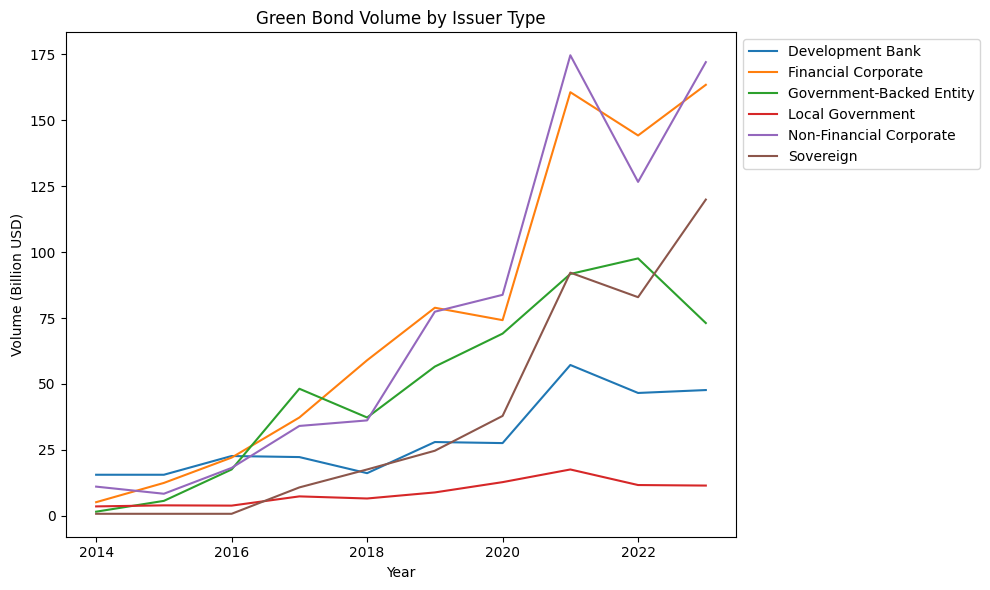

In [20]:
# Summary of total issuance by year for issuer type
issuer_summary = issuertype_df.set_index('Issuer Type').T
issuer_summary.describe()

# Plot green bond volumes over time by issuer type
issuer_summary.plot(figsize=(10,6), title='Green Bond Volume by Issuer Type')
plt.ylabel('Volume (Billion USD)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('issuancebytype.png')
plt.show() 

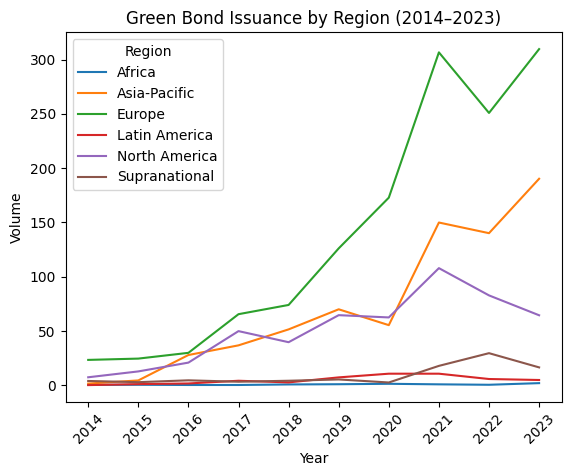

In [21]:
# Total green bonds issued by region per year
region_melted = regionissued_df.melt(id_vars='Region', var_name='Year', value_name='Volume')
sns.lineplot(data=region_melted, x='Year', y='Volume', hue='Region')
plt.title('Green Bond Issuance by Region (2014–2023)')
plt.xticks(rotation=45)
plt.savefig('issuancebyregion.png')
plt.show()

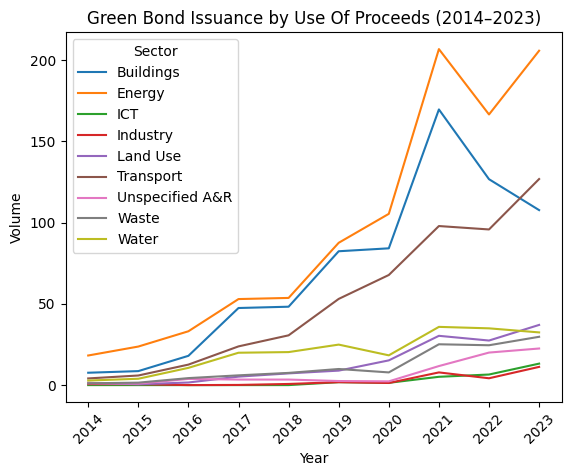

In [22]:
# Total green bonds issued by use of proceeds per year
uop_melted = useofproceeds_df.melt(id_vars='Sector', var_name='Year', value_name='Volume')
sns.lineplot(data=uop_melted, x='Year', y='Volume', hue='Sector')
plt.title('Green Bond Issuance by Use Of Proceeds (2014–2023)')
plt.xticks(rotation=45)
plt.savefig('issuancebyuop.png')
plt.show()

### Trend Analysis

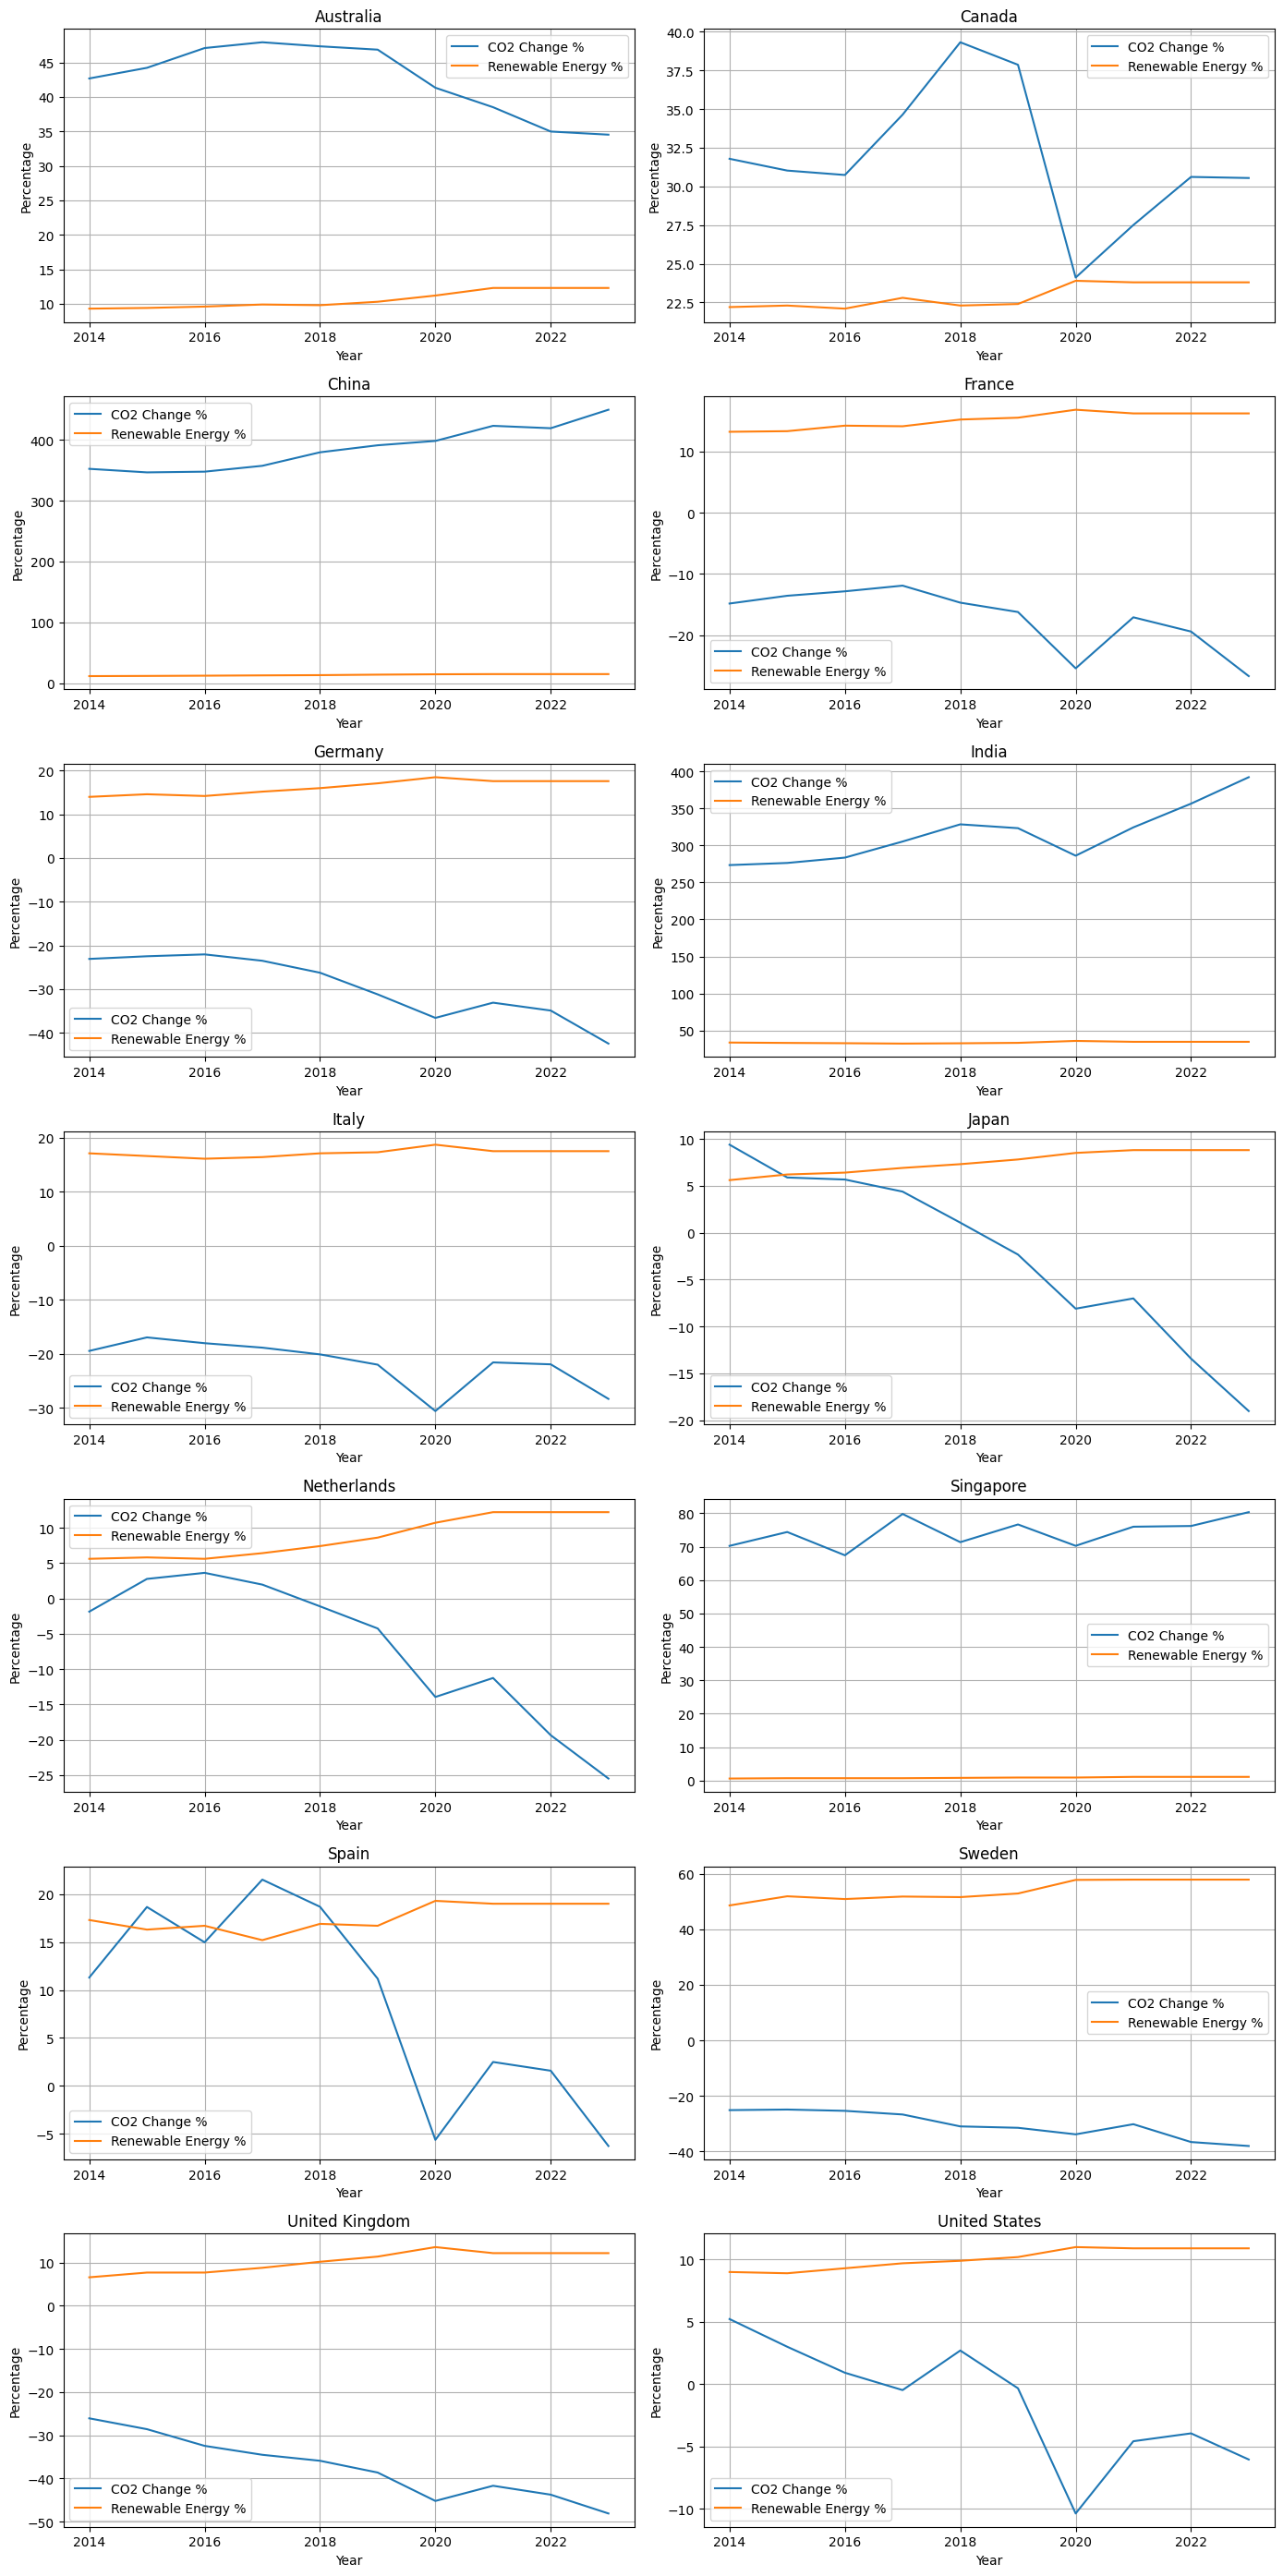

In [23]:
# Convert Year to numeric if needed
worldbankfin_df['Year'] = pd.to_numeric(worldbankfin_df['Year'], errors='coerce')

# Unique countries
countries = worldbankfin_df['Country Name'].unique()

# Create 7x2 grid (14 countries, 2 per row)
fig, axes = plt.subplots(7, 2, figsize=(14, 28))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    data = worldbankfin_df[worldbankfin_df['Country Name'] == country]

    sns.lineplot(data=data, x='Year',
                 y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)',
                 label='CO2 Change %', ax=ax)
    sns.lineplot(data=data, x='Year',
                 y='Renewable energy consumption (% of total final energy consumption)',
                 label='Renewable Energy %', ax=ax)

    ax.set_title(country)
    ax.set_xlabel('Year')
    ax.set_ylabel('Percentage')
    ax.legend()
    ax.grid(True)


plt.tight_layout()
plt.savefig('trendbycountry.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis

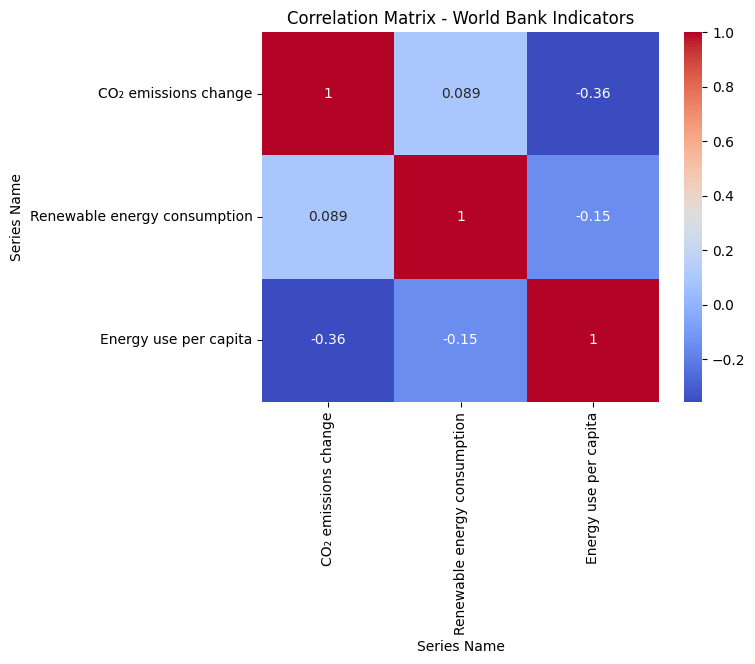

In [24]:
# Correlation between emissions change and renewable energy for all countries
corr_df = worldbankfin_df[['Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)', 
                      'Renewable energy consumption (% of total final energy consumption)',
                      'Energy use (kg of oil equivalent per capita)']].dropna()

# Create shorter names for the columns to improve readability
column_names = {
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)': 'CO₂ emissions change',
    'Renewable energy consumption (% of total final energy consumption)': 'Renewable energy consumption',
    'Energy use (kg of oil equivalent per capita)': 'Energy use per capita'
}

# Rename the columns for plotting
plot_df = corr_df.rename(columns=column_names)

# Calculate correlation matrix
correlation_matrix = plot_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - World Bank Indicators')
plt.savefig('correlationmat.png')
plt.show()

### Regression Analysis

In [25]:
# Regression: CO2 emissions change ~ Renewable energy + Energy use
df = worldbankfin_df.dropna()
X = df[['Renewable energy consumption (% of total final energy consumption)', 
        'Energy use (kg of oil equivalent per capita)']]
y = df['Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)']

In [26]:
# Add constant for intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                                                         OLS Regression Results                                                         
Dep. Variable:     Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)   R-squared:                       0.129
Model:                                                                                      OLS   Adj. R-squared:                  0.116
Method:                                                                           Least Squares   F-statistic:                     10.11
Date:                                                                          Wed, 30 Apr 2025   Prob (F-statistic):           8.05e-05
Time:                                                                                  02:26:21   Log-Likelihood:                -867.75
No. Observations:                                                                           140   AIC:                             1741.
Df Residuals:                            

In [27]:
# Get the model summary as a DataFrame
summary_df = model.summary2().tables[1]

# Save it to a CSV
summary_df.to_csv('ols_regression_results.csv', index=True)